In [ ]:
# RAG

In [12]:
import os
import time

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [2]:
from dotenv import load_dotenv
load_dotenv()

llm = ChatOpenAI(model = 'gpt-4o-mini')

In [5]:
embedding_model = OpenAIEmbeddings(model='text-embedding-3-small')

In [6]:
test_emb = embedding_model.embed_query('Hello')

In [7]:
from langchain_classic.embeddings import CacheBackedEmbeddings # 내부적으로 InMemoryByteStore에 저장하도록 처리
from langchain_core.stores import InMemoryByteStore

In [9]:
# 위에서 만든 embedding_model store에 저장한다는 내용
store = InMemoryByteStore()
chached_embeddings = CacheBackedEmbeddings.from_bytes_store(
    embedding_model, store, namespace="embedding-cache"
)

/Users/jeonginjeon/Desktop/LLM/.venv/lib/python3.10/site-packages/langchain_classic/embeddings/cache.py:58: UserWarning: Using default key encoder: SHA-1 is *not* collision-resistant. While acceptable for most cache scenarios, a motivated attacker can craft two different payloads that map to the same cache key. If that risk matters in your environment, supply a stronger encoder (e.g. SHA-256 or BLAKE2) via the `key_encoder` argument. If you change the key encoder, consider also creating a new cache, to avoid (the potential for) collisions with existing keys.
  _warn_about_sha1_encoder()


In [10]:
texts = ["인공지능이 계속 발전하고 있습니다.", "Langchain으로 RAG를 구현합시다."]
vecs1 = embedding_model.embed_documents(texts)

In [11]:
len(vecs1)

2

In [13]:
# 다음에 짧아질 수 있는 것은 임베딩 모델을 이용해서 사용한 후 2번째는 서버에 값이 저장되어있기 때문에 시간이 단축 될 수 있음
start = time.time()
texts = ["오늘 점심에는 라면을 먹었습니다.", "내일 저녁에는 햄버거를 먹을겁니다."]
vecs1 = embedding_model.embed_documents(texts)
t1 = time.time() - start
print(f"1차 call, {t1}초")

start = time.time()
vecs2 = embedding_model.embed_documents(texts)
t2 = time.time() - start
print(f"2차 call, {t2}초")

1차 call, 0.4390420913696289초
2차 call, 0.11575603485107422초


In [18]:
"""
chunking은 긴 문서를 의미 단위로 분할하는 과정이고,
batching은 여러 문서를 묶어서 효율적으로 처리하기 위한 방식이다.
batch들을 처리하면서 docs를 전체 백터처리
중간에는 batch가 끝날때마다 실행시간, 처리토큰을 출력하는 함수
모든 문서가 완료되었을 때, 소요시간과 전체 처리토큰을 출력
"""
def process_documents(docs, embedding_model, batch_size=5):
    all_vectors = []
    total_tokens = 0

    start_time = time.time()

    for i in range(0, len(docs), batch_size):
        batch = docs[i:i + batch_size]

        batch_start = time.time()

        # 임베딩
        vectors = embedding_model.embed_documents(batch)
        all_vectors.extend(vectors)

        # 토큰 계산
        batch_tokens = sum(len(doc) for doc in batch)
        total_tokens += batch_tokens

        batch_time = time.time() - batch_start

        print(f"[Batch {i//batch_size + 1}]")
        print(f"- 문서 수: {len(batch)}")
        print(f"- 처리 토큰: {batch_tokens}")
        print(f"- 소요 시간: {batch_time:.2f}s\n")

    total_time = time.time() - start_time

    print("="*40)
    print(f"총 문서 수: {len(docs)}")
    print(f"총 토큰 수: {total_tokens}")
    print(f"총 소요 시간: {total_time:.2f}s")

    return all_vectors

In [17]:
docs = [
    "AI 기술이 발전하고 있다",
    "야구 경기가 재미있다",
    "치킨이 먹고 싶다",
    "클라우드 서비스가 중요하다",
    "올림픽에서 금메달",
    "김치는 맛있다"
]

vectors = process_documents(docs, embedding_model, batch_size=5)

[Batch 1]
- 문서 수: 5
- 처리 토큰: 57
- 소요 시간: 0.18s

[Batch 2]
- 문서 수: 1
- 처리 토큰: 7
- 소요 시간: 0.16s

총 문서 수: 6
총 토큰 수: 64
총 소요 시간: 0.33s


In [19]:
import tiktoken

def count_token(text, model='gpt-4o-mini'):
    enc = tiktoken.encoding_for_model(model)
    return len(enc.encode(text))

In [23]:
# ex)문서가 11개 라면 문서를 5, 5, 1 실행
def process_documents(docs, embedding_model, batch_size=5):
    all_vectors = []
    total_tokens = 0

    start = time.time()

    for i in range(0, len(docs), batch_size):
        batch = docs[i:i+batch_size]
        batch_tokens = sum(count_token(d) for d in batch)
        total_tokens += batch_tokens

        vectors = embedding_model.embed_documents(batch)
        all_vectors.extend(vectors)

        progress = min(i+batch_size, len(docs))
        print(f"[{progress}/{len(docs)}] batch {i//batch_size + 1} progress ({batch_tokens} tokens)")

    elapsed = time.time() - start
    print(f"completed, {len(docs)} documents, {total_tokens} tokens completed")
    print(f"{elapsed} seconds")
    return all_vectors

In [24]:
docs = [f"doc {i} : 이것은 테스트 문서입니다. 인공지능에 관련한 문서입니다." for i in range(20)]
vectors = process_documents(docs, chached_embeddings)

[5/20] batch 1 progress (105 tokens)
[10/20] batch 2 progress (105 tokens)
[15/20] batch 3 progress (105 tokens)
[20/20] batch 4 progress (105 tokens)
completed, 20 documents, 420 tokens completed
0.013885974884033203 seconds


In [25]:
from sklearn.metrics.pairwise import cosine_similarity

In [29]:
# cosine_similarity : 자연어 데이터는 백터 형식으로 볼 예정(연관성, 유사도 문서도, 카테고리 문서도)
# 두 벡터가 1일때 유사, -1는 전혀 다름 벡터의 유사도 확인용

pairs= [
    ("오늘 날씨가 좋다", "오늘은 화창한 날이다"),
    ("오늘 날씨가 좋다", "날씨가 나쁘다"),
    ("파이썬 프로그래밍", "python programming"),
    ("인공지능 기술", "맛있는 김치찌개"),
    ("서울은 한국의 수도입니다", "seoul is the capital of korea")
]

In [30]:
for text_a, text_b in pairs:
    embs = embedding_model.embed_documents([text_a, text_b])
    sim = cosine_similarity([embs[0]], [embs[1]])[0][0]

    print(f"similarity : {sim}, {text_a}, {text_b}")

similarity : 0.6269659080406769, 오늘 날씨가 좋다, 오늘은 화창한 날이다
similarity : 0.5242631315416773, 오늘 날씨가 좋다, 날씨가 나쁘다
similarity : 0.38607526343848175, 파이썬 프로그래밍, python programming
similarity : 0.1490592988406505, 인공지능 기술, 맛있는 김치찌개
similarity : 0.5090119592414086, 서울은 한국의 수도입니다, seoul is the capital of korea


In [31]:
corpus = [
    "LangChain은 LLM 앱 개발 프레임워크입니다",
    "RAG는 검색 증강 생성 기술입니다",
    "벡터 데이터베이스는 임베딩을 저장합니다",
    "파인튜닝은 모델을 특정 데이터에 맞게 조정합니다",
    "프롬프트 엔지니어링은 AI에게 좋은 지시를 작성하는 기술입니다",
    "LangChain으로 챗봇 만들기",
    "React vs Vue 성능 비교",
    "GPT API 활용 가이드",
]

In [36]:
# vectorize, query와의 cosine_similatiry를 계상해서 가장 유사한 문장을 return 
def find_most_similar(query, corpus):
    # 1. query embedding
    query_vec = embeddings_model.embed_query(query)

    # 2. corpus embedding
    corpus_vecs = [
        embeddings_model.embed_query(doc)
        for doc in corpus
    ]

    # 3. cosine similarity 계산
    similarities = cosine_similarity(
        [query_vec],
        corpus_vecs
    )[0]

    # 4. 가장 유사한 문장 선택
    best_idx = similarities.argmax()

    return corpus[best_idx], similarities[best_idx]

In [41]:
def find_most_similar(query, corpus, top_k = 3):
    all_texts = [query] + corpus
    all_embs = embedding_model.embed_documents(all_texts)

    query_emb = all_embs[0]
    corpus_emb = all_embs[1:]

    sims = cosine_similarity([query_emb], corpus_emb)[0]
    ranked = sorted(enumerate(sims), key=lambda x:x[1], reverse=True)

    for rank, (idx, sim) in enumerate(ranked):
        print(f"{rank} sim : {sim}, {corpus[idx]}")

    return ranked[:top_k]

In [42]:
find_most_similar('AI 챗봇 개발 하고 싶어요', corpus)

0 sim : 0.5941716068957739, LangChain으로 챗봇 만들기
1 sim : 0.3158226104927049, LangChain은 LLM 앱 개발 프레임워크입니다
2 sim : 0.26494902447471946, 프롬프트 엔지니어링은 AI에게 좋은 지시를 작성하는 기술입니다
3 sim : 0.2382909715052333, RAG는 검색 증강 생성 기술입니다
4 sim : 0.2116065770611965, GPT API 활용 가이드
5 sim : 0.20454574979091225, 파인튜닝은 모델을 특정 데이터에 맞게 조정합니다
6 sim : 0.18516886029415514, 벡터 데이터베이스는 임베딩을 저장합니다
7 sim : 0.15126786463438777, React vs Vue 성능 비교


[(5, np.float64(0.5941716068957739)),
 (0, np.float64(0.3158226104927049)),
 (4, np.float64(0.26494902447471946))]

In [58]:
# 차원 축소
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE # 가까이 있는 애들을 가깝게 멀리있는 애들은 멀게

In [43]:
topic_sentences = {
    "tech": [
        "인공지능이 산업을 혁신하고 있다",
        "클라우드 컴퓨팅이 IT를 변화시킨다",
        "블록체인이 금융을 바꾸고 있다",
        "5G가 통신을 혁신한다",
    ],
    "sports": [
        "축구 경기에서 역전골이 터졌다",
        "올림픽에서 금메달을 획득했다",
        "야구 시즌이 개막했다",
        "마라톤 대회에서 신기록을 세웠다",
    ],
    "food": [
        "이 레스토랑의 파스타가 맛있었다",
        "한국 김치는 발효 식품이다",
        "새로운 카페에서 커피를 마셨다",
        "맛집 탐방이 요즘 인기다",
    ],
    "finance": [
        "주식 시장이 크게 하락했다",
        "비트코인 가격이 급등했다",
        "금리 인상이 예상된다",
        "환율이 급변하고 있다",
    ],
}

In [45]:
all_texts = []
all_labels = []
for topic, sents in topic_sentences.items():
    all_texts.extend(sents)
    all_labels.extend([topic] * len(sents))

In [48]:
all_embs = embedding_model.embed_documents(all_texts)
len(all_embs)

16

In [49]:
import numpy as np

emb_matrix = np.array(all_embs)

In [50]:
emb_matrix

array([[ 5.53131104e-03,  8.70513916e-03,  2.40173340e-02, ...,
        -1.49459839e-02, -1.50394440e-03,  1.42974854e-02],
       [-1.26266479e-02,  8.85772705e-03,  3.22265625e-02, ...,
        -5.47180176e-02,  7.98797607e-03, -2.30865479e-02],
       [-1.30462646e-02,  4.10766602e-02, -1.60369873e-02, ...,
        -1.86614990e-02,  1.55868530e-02,  3.84521484e-03],
       ...,
       [-2.75268555e-02, -3.58581543e-02, -2.79998779e-02, ...,
         8.47625732e-03, -3.39150429e-05,  2.29949951e-02],
       [ 3.85742188e-02,  2.89611816e-02, -2.80303955e-02, ...,
        -9.64355469e-03,  1.01318359e-02,  8.15391541e-04],
       [-1.81732178e-02,  4.37545776e-03,  6.41632080e-03, ...,
        -1.42745972e-02, -2.41699219e-02, -1.98669434e-02]],
      shape=(16, 1536))

In [53]:
# Principal Components Analysis
pca = PCA(n_components=2)
# fit_transform 행렬에 대해서 pca 연산처리를 하는 것
coords_2d = pca.fit_transform(emb_matrix)

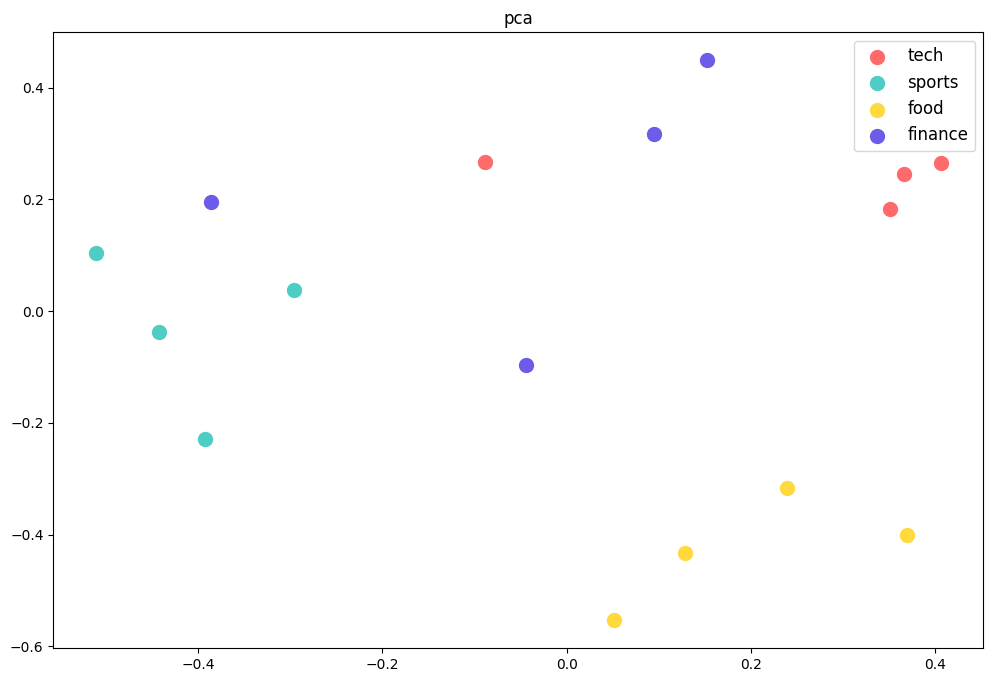

In [56]:
import matplotlib.pyplot as plt

colors = {"tech": "#FF6B6B", "sports": "#4ECDC4", "food": "#FFD93D", "finance": "#6C5CE7"}
fig, ax = plt.subplots(figsize=(12,8))
for topic in topic_sentences:
    # 토픽에 해당되는 애들을 같은 색상으로 처리하기 위해서 처리
    mask = [l == topic for l in all_labels]
    x = coords_2d[mask, 0]
    y = coords_2d[mask, 1]
    ax.scatter(x,y, c=colors[topic], label=topic, s=100)

ax.legend(fontsize=12)
ax.set_title('pca')
plt.show()

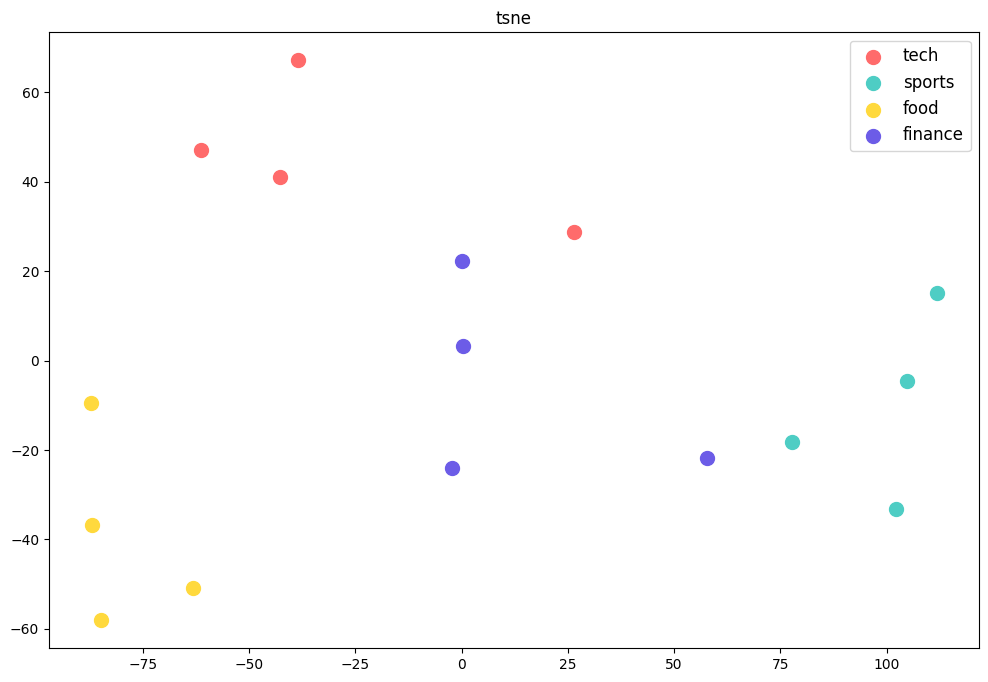

In [57]:
# perplexity 주의에 몇개를 한 묶음으로 볼 것인지
tsne = TSNE(n_components=2, perplexity=5)
coords_tsne = tsne.fit_transform(emb_matrix)

fig, ax = plt.subplots(figsize=(12,8))
for topic in topic_sentences:
    # 토픽에 해당되는 애들을 같은 색상으로 처리하기 위해서 처리
    mask = [l == topic for l in all_labels]
    x = coords_tsne[mask, 0]
    y = coords_tsne[mask, 1]
    ax.scatter(x,y, c=colors[topic], label=topic, s=100)

ax.legend(fontsize=12)
ax.set_title('tsne')
plt.show()

In [60]:
# FAISS (Facebook AI Similarity Search)
from langchain_community.vectorstores import FAISS

In [61]:
faq_docs = [
    "LangChain은 LLM 애플리케이션 개발을 위한 프레임워크입니다.",
    "RAG는 외부 문서를 검색하여 LLM 답변 정확도를 높이는 기술입니다.",
    "벡터 데이터베이스는 임베딩 벡터를 효율적으로 저장하고 검색합니다.",
    "프롬프트 엔지니어링은 AI에게 효과적인 지시를 작성하는 기술입니다.",
    "파인튜닝은 사전학습된 모델을 특정 도메인 데이터로 추가 학습시킵니다.",
    "토큰은 LLM이 텍스트를 처리하는 기본 단위입니다.",
    "임베딩은 텍스트를 수치 벡터로 변환하는 기술입니다.",
    "LCEL은 LangChain의 체인 구성을 위한 표현식 언어입니다.",
    "에이전트는 LLM이 도구를 사용해서 자율적으로 작업하는 시스템입니다.",
    "Gradio는 ML 모델을 위한 간단한 웹 인터페이스를 만드는 라이브러리입니다.",
]

In [64]:
vectorstore = FAISS.from_texts(faq_docs, embedding_model)

In [63]:
!uv add faiss-cpu

Resolved 195 packages in 501ms                                       
Prepared 1 package in 886ms                                              
Installed 1 package in 7ms                                  
 + faiss-cpu==1.13.2


In [65]:
from langchain_core.documents import Document

In [66]:
docs_with_meta = [
    Document(page_content = 'Langchain은 LLM앱 개발 프레임워크입니다', metadata = {'category' : 'framework', 'level' : 'beginner'}),
    Document(page_content = 'RAG는 검색증강생성 기술입니다', metadata = {'category' : 'technique', 'level' : 'intermediate'}),
    Document(page_content = 'FAISS는 벡터 유사도 검색 라이브러리입니다', metadata = {'category' : 'tool', 'level' : 'intermediate'}),
    Document(page_content = '프롬프트 엔지니어링은 AI 지시를 작성하는 기술입니다', metadata = {'category' : 'technique', 'level' : 'beginner'}),
    Document(page_content = '에이전트는 LLM이 도구를 자율적으로 사용하는 시스템입니다', metadata = {'category' : 'technique', 'level' : 'advanced'}),
]

vs_meta = FAISS.from_documents(docs_with_meta, embedding_model)

In [67]:
vs_meta

In [69]:
results = vs_meta.similarity_search('AI 개발 도구', k=3)

In [70]:
results

[Document(id='1774e048-b2e0-48dc-b0b6-836668eb055e', metadata={'category': 'technique', 'level': 'beginner'}, page_content='프롬프트 엔지니어링은 AI 지시를 작성하는 기술입니다'),
 Document(id='fb6b45e9-d6ef-4674-a050-0671dfc9ffc9', metadata={'category': 'technique', 'level': 'advanced'}, page_content='에이전트는 LLM이 도구를 자율적으로 사용하는 시스템입니다'),
 Document(id='ea229f72-0b54-4e8e-89b1-bc27df5d32f8', metadata={'category': 'framework', 'level': 'beginner'}, page_content='Langchain은 LLM앱 개발 프레임워크입니다')]

In [73]:
for doc in results:
    print(f"[{doc.metadata['category']}], {doc.metadata['level']}, {doc.page_content}")

[technique], beginner, 프롬프트 엔지니어링은 AI 지시를 작성하는 기술입니다
[technique], advanced, 에이전트는 LLM이 도구를 자율적으로 사용하는 시스템입니다
[framework], beginner, Langchain은 LLM앱 개발 프레임워크입니다


In [ ]:
# 임베딩 모델에서 지원을 해야지만 사용이 가능(다국어에 대한 내용) 사용하는 모델 확인 필요

In [74]:
multilingual = [
    ('인공지능이 세상을 바꾸고 있다', '한국어'),
    ('Artificial inteligence is changing the world', '영어'),
    ('나는 학교에 갑니다', '한국어'),
    ('I go home', '영어')
]

texts = [t for t, l in multilingual]
langs = [l for t, l in multilingual]

In [76]:
embs_multi = embedding_model.embed_documents(texts)
sim_matrix = cosine_similarity(embs_multi)

sim_matrix

array([[ 1.        ,  0.60158619,  0.09073573,  0.06148136],
       [ 0.60158619,  1.        , -0.01850748,  0.05518189],
       [ 0.09073573, -0.01850748,  1.        ,  0.29727779],
       [ 0.06148136,  0.05518189,  0.29727779,  1.        ]])

In [78]:
# 교차 검색에 대한 내용 확인
english_docs = [
    "LangChain is a framework for building LLM applications.",
    "RAG improves LLM accuracy by retrieving external documents.",
    "Vector databases store and search embedding vectors efficiently.",
    "Fine-tuning adapts a pre-trained model to specific data.",
    "Prompt engineering is the art of crafting effective instructions for AI.",
]

vs_en = FAISS.from_texts(english_docs, embedding_model)

ko_queries = [
    "RAG가 뭐에요?", "벡터 데이터베이스 설명해주세요", "프롬프트 엔지니어링은?" 
]

for q in ko_queries:
    results = vs_en.similarity_search_with_score(q, k=1)
    print(f"\nKR {q}")

    for doc, score in results:
        print(f"US {score}, {doc.page_content}")


KR RAG가 뭐에요?
US 1.0923924446105957, RAG improves LLM accuracy by retrieving external documents.

KR 벡터 데이터베이스 설명해주세요
US 1.456146240234375, Vector databases store and search embedding vectors efficiently.

KR 프롬프트 엔지니어링은?
US 1.5417664051055908, Prompt engineering is the art of crafting effective instructions for AI.
